1. MNIST 최적화

이미지 크기: 28x28 (MNIST 기본)
패치 크기: 4x4 (7x7 = 49개 패치)
채널: 1 (그레이스케일)

2. 경량화된 구조

인코더: 6층, 192차원, 3개 헤드
디코더: 4층, 128차원, 4개 헤드
빠른 학습을 위해 파라미터 수 최적화

3. 완전한 End-to-End

데이터 로딩부터 시각화까지 모든 과정 포함
학습 전후 결과 비교 가능
진행상황 표시바 포함

사용 중인 디바이스: cuda
MNIST MAE 학습 시작!
데이터 로딩 중...


100%|██████████| 9.91M/9.91M [00:00<00:00, 17.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 493kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.59MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.59MB/s]


학습 데이터: 60000개
모델 생성 중...
모델 매개변수 수: 3,509,264

학습 전 MAE 결과:


<ipython-input-1-15f3ee1b9d0d>:355: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-1-15f3ee1b9d0d>:355: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-1-15f3ee1b9d0d>:355: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-1-15f3ee1b9d0d>:355: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-1-15f3ee1b9d0d>:355: UserWarning: Glyph 53433 (\N{HANGUL SYLLABLE KING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-1-15f3ee1b9d0d>:355: UserWarning: Glyph 51116 (\N{HANGUL SYLLABLE JAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-1-15f3ee1b9d0d>:355: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipyth

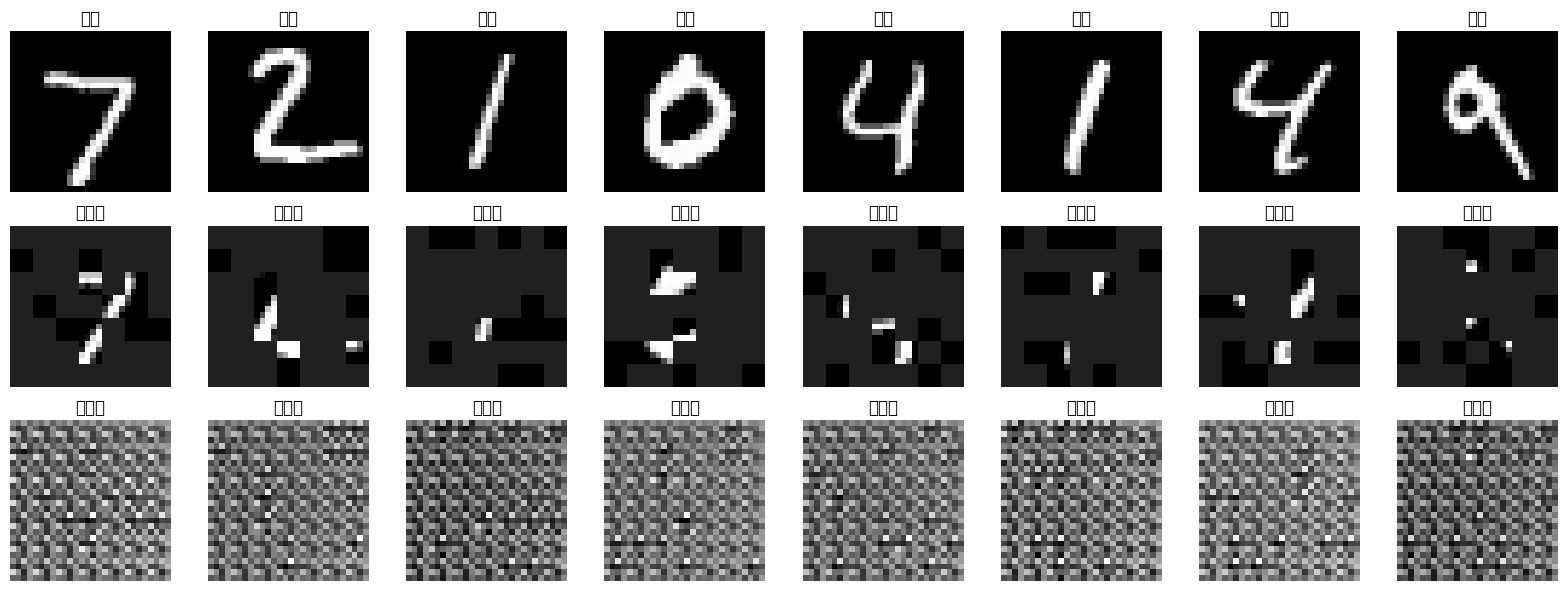

재구성 손실: 1.7025

5 에폭 학습 시작...


Epoch 1/5: 100%|██████████| 469/469 [00:25<00:00, 18.23it/s, loss=0.6608]


Epoch 1, 평균 손실: 0.7479


Epoch 2/5: 100%|██████████| 469/469 [00:26<00:00, 17.46it/s, loss=0.4704]


Epoch 2, 평균 손실: 0.5974


...

Epoch 3, 평균 손실: 0.4508


Epoch 4/5: 100%|██████████| 469/469 [00:25<00:00, 18.40it/s, loss=0.3505]


Epoch 4, 평균 손실: 0.3874


Epoch 5/5: 100%|██████████| 469/469 [00:25<00:00, 18.67it/s, loss=0.3246]

Epoch 5, 평균 손실: 0.3585

학습 후 MAE 결과:


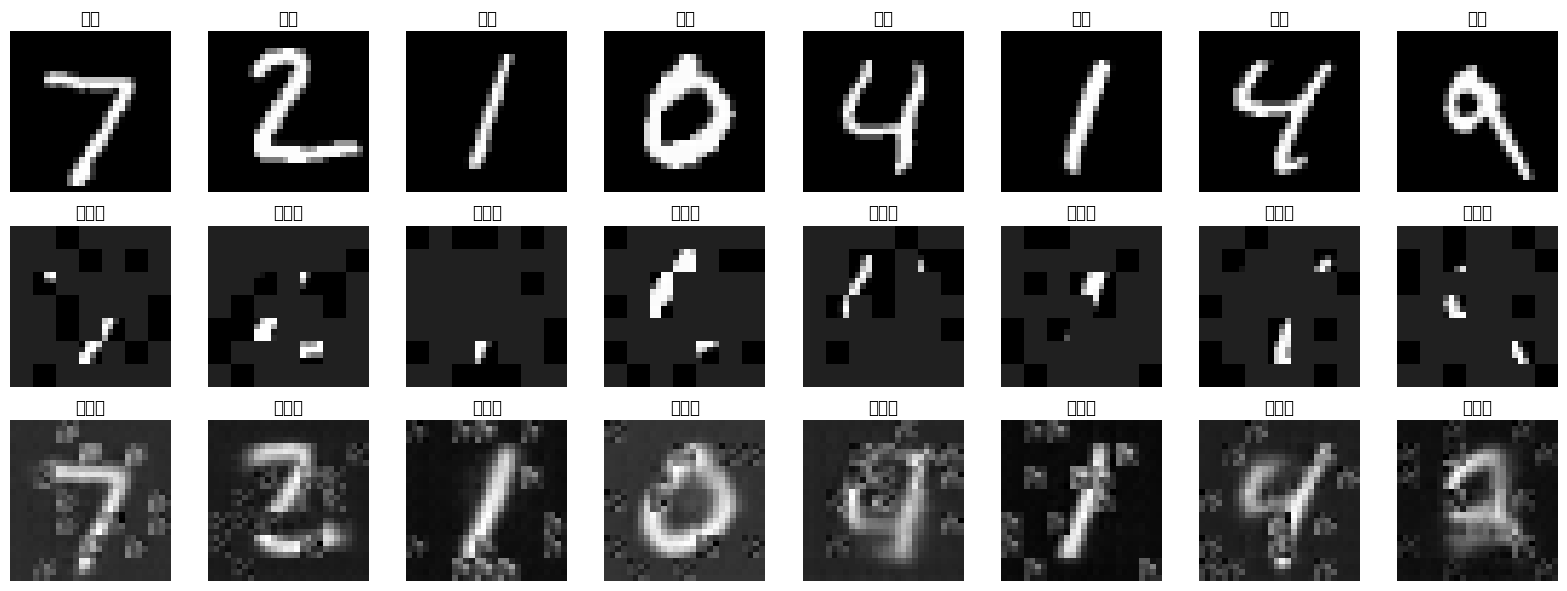

재구성 손실: 0.2956

학습 완료!


In [1]:
# MAE (Masked Autoencoder) for MNIST - Colab용 구현
# 빠른 학습을 위해 경량화된 버전

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import math

# GPU 사용 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"사용 중인 디바이스: {device}")

# 2D Sin-Cos 위치 임베딩 생성 함수
def get_2d_sincos_pos_embed(embed_dim, grid_size, cls_token=False):
    """
    2D 위치에 대한 sin-cos 임베딩 생성
    """
    grid_h = np.arange(grid_size, dtype=np.float32)
    grid_w = np.arange(grid_size, dtype=np.float32)
    grid = np.meshgrid(grid_w, grid_h)  # w, h 순서
    grid = np.stack(grid, axis=0)

    grid = grid.reshape([2, 1, grid_size, grid_size])
    pos_embed = get_2d_sincos_pos_embed_from_grid(embed_dim, grid)
    if cls_token:
        pos_embed = np.concatenate([np.zeros([1, embed_dim]), pos_embed], axis=0)
    return pos_embed

def get_2d_sincos_pos_embed_from_grid(embed_dim, grid):
    assert embed_dim % 2 == 0

    # 각 차원에 대해 임베딩 생성
    emb_h = get_1d_sincos_pos_embed_from_grid(embed_dim // 2, grid[0])  # (H*W, D/2)
    emb_w = get_1d_sincos_pos_embed_from_grid(embed_dim // 2, grid[1])  # (H*W, D/2)

    emb = np.concatenate([emb_h, emb_w], axis=1) # (H*W, D)
    return emb

def get_1d_sincos_pos_embed_from_grid(embed_dim, pos):
    """
    embed_dim: 출력 차원
    pos: M개의 위치 리스트
    out: (M, D)
    """
    assert embed_dim % 2 == 0
    omega = np.arange(embed_dim // 2, dtype=np.float32)
    omega /= embed_dim / 2.
    omega = 1. / 10000**omega  # (D/2,)

    pos = pos.reshape(-1)  # (M,)
    out = np.einsum('m,d->md', pos, omega)  # (M, D/2), 외적

    emb_sin = np.sin(out) # (M, D/2)
    emb_cos = np.cos(out) # (M, D/2)

    emb = np.concatenate([emb_sin, emb_cos], axis=1)  # (M, D)
    return emb

# 간단한 패치 임베딩 레이어
class PatchEmbed(nn.Module):
    """이미지를 패치로 나누고 임베딩"""
    def __init__(self, img_size=28, patch_size=4, in_chans=1, embed_dim=192):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2

        # 패치를 임베딩으로 변환하는 컨볼루션 레이어
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        B, C, H, W = x.shape
        x = self.proj(x)  # (B, embed_dim, H/patch_size, W/patch_size)
        x = x.flatten(2).transpose(1, 2)  # (B, num_patches, embed_dim)
        return x

# 트랜스포머 블록
class Block(nn.Module):
    """트랜스포머 블록 (Multi-Head Attention + MLP)"""
    def __init__(self, embed_dim, num_heads, mlp_ratio=4., dropout=0.):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(embed_dim)

        mlp_hidden_dim = int(embed_dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden_dim, embed_dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        # Self-Attention
        x_norm = self.norm1(x)
        attn_out, _ = self.attn(x_norm, x_norm, x_norm, need_weights=False)
        x = x + attn_out

        # MLP
        x = x + self.mlp(self.norm2(x))
        return x

# MAE 모델 (MNIST용으로 경량화)
class MaskedAutoencoderViT(nn.Module):
    """MNIST용 Masked Autoencoder"""
    def __init__(self, img_size=28, patch_size=4, in_chans=1,
                 embed_dim=192, depth=6, num_heads=3,
                 decoder_embed_dim=128, decoder_depth=4, decoder_num_heads=4,
                 mlp_ratio=4., norm_pix_loss=False):
        super().__init__()

        # 인코더 구성요소
        self.patch_embed = PatchEmbed(img_size, patch_size, in_chans, embed_dim)
        num_patches = self.patch_embed.num_patches

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim), requires_grad=False)

        self.blocks = nn.ModuleList([
            Block(embed_dim, num_heads, mlp_ratio) for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)

        # 디코더 구성요소
        self.decoder_embed = nn.Linear(embed_dim, decoder_embed_dim, bias=True)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, decoder_embed_dim))
        self.decoder_pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, decoder_embed_dim), requires_grad=False)

        self.decoder_blocks = nn.ModuleList([
            Block(decoder_embed_dim, decoder_num_heads, mlp_ratio) for _ in range(decoder_depth)
        ])

        self.decoder_norm = nn.LayerNorm(decoder_embed_dim)
        self.decoder_pred = nn.Linear(decoder_embed_dim, patch_size**2 * in_chans, bias=True)

        self.norm_pix_loss = norm_pix_loss
        self.initialize_weights()

    def initialize_weights(self):
        """가중치 초기화"""
        # 위치 임베딩 초기화
        pos_embed = get_2d_sincos_pos_embed(self.pos_embed.shape[-1],
                                           int(self.patch_embed.num_patches**0.5), cls_token=True)
        self.pos_embed.data.copy_(torch.from_numpy(pos_embed).float().unsqueeze(0))

        decoder_pos_embed = get_2d_sincos_pos_embed(self.decoder_pos_embed.shape[-1],
                                                   int(self.patch_embed.num_patches**0.5), cls_token=True)
        self.decoder_pos_embed.data.copy_(torch.from_numpy(decoder_pos_embed).float().unsqueeze(0))

        # 토큰 초기화
        torch.nn.init.normal_(self.cls_token, std=0.02)
        torch.nn.init.normal_(self.mask_token, std=0.02)

        # 선형 레이어 초기화
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            torch.nn.init.xavier_uniform_(m.weight)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)

    def patchify(self, imgs):
        """이미지를 패치로 분할"""
        p = self.patch_embed.patch_size
        assert imgs.shape[2] == imgs.shape[3] and imgs.shape[2] % p == 0

        h = w = imgs.shape[2] // p
        x = imgs.reshape(imgs.shape[0], 1, h, p, w, p)
        x = torch.einsum('nchpwq->nhwpqc', x)
        x = x.reshape(imgs.shape[0], h * w, p**2 * 1)
        return x

    def unpatchify(self, x):
        """패치를 이미지로 재구성"""
        p = self.patch_embed.patch_size
        h = w = int(x.shape[1]**0.5)

        x = x.reshape(x.shape[0], h, w, p, p, 1)
        x = torch.einsum('nhwpqc->nchpwq', x)
        imgs = x.reshape(x.shape[0], 1, h * p, w * p)
        return imgs

    def random_masking(self, x, mask_ratio):
        """랜덤 마스킹 수행"""
        N, L, D = x.shape
        len_keep = int(L * (1 - mask_ratio))

        noise = torch.rand(N, L, device=x.device)

        # 각 샘플에 대해 노이즈 정렬
        ids_shuffle = torch.argsort(noise, dim=1)
        ids_restore = torch.argsort(ids_shuffle, dim=1)

        # 유지할 패치 인덱스
        ids_keep = ids_shuffle[:, :len_keep]
        x_masked = torch.gather(x, dim=1, index=ids_keep.unsqueeze(-1).repeat(1, 1, D))

        # 이진 마스크 생성 (0은 유지, 1은 제거)
        mask = torch.ones([N, L], device=x.device)
        mask[:, :len_keep] = 0
        mask = torch.gather(mask, dim=1, index=ids_restore)

        return x_masked, mask, ids_restore

    def forward_encoder(self, x, mask_ratio):
        """인코더 forward"""
        # 패치 임베딩
        x = self.patch_embed(x)

        # 위치 임베딩 추가 (cls 토큰 제외)
        x = x + self.pos_embed[:, 1:, :]

        # 마스킹
        x, mask, ids_restore = self.random_masking(x, mask_ratio)

        # cls 토큰 추가
        cls_token = self.cls_token + self.pos_embed[:, :1, :]
        cls_tokens = cls_token.expand(x.shape[0], -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)

        # 트랜스포머 블록 적용
        for blk in self.blocks:
            x = blk(x)
        x = self.norm(x)

        return x, mask, ids_restore

    def forward_decoder(self, x, ids_restore):
        """디코더 forward"""
        # 임베딩
        x = self.decoder_embed(x)

        # 마스크 토큰 추가
        mask_tokens = self.mask_token.repeat(x.shape[0], ids_restore.shape[1] + 1 - x.shape[1], 1)
        x_ = torch.cat([x[:, 1:, :], mask_tokens], dim=1)  # cls 토큰 제외
        x_ = torch.gather(x_, dim=1, index=ids_restore.unsqueeze(-1).repeat(1, 1, x.shape[2]))
        x = torch.cat([x[:, :1, :], x_], dim=1)  # cls 토큰 추가

        # 위치 임베딩 추가
        x = x + self.decoder_pos_embed

        # 트랜스포머 블록 적용
        for blk in self.decoder_blocks:
            x = blk(x)
        x = self.decoder_norm(x)

        # 예측
        x = self.decoder_pred(x)

        # cls 토큰 제거
        x = x[:, 1:, :]

        return x

    def forward_loss(self, imgs, pred, mask):
        """손실 계산"""
        target = self.patchify(imgs)
        if self.norm_pix_loss:
            mean = target.mean(dim=-1, keepdim=True)
            var = target.var(dim=-1, keepdim=True)
            target = (target - mean) / (var + 1e-6)**0.5

        loss = (pred - target) ** 2
        loss = loss.mean(dim=-1)  # 패치별 평균 손실

        loss = (loss * mask).sum() / mask.sum()  # 마스크된 패치에 대한 평균 손실
        return loss

    def forward(self, imgs, mask_ratio=0.75):
        """전체 forward pass"""
        latent, mask, ids_restore = self.forward_encoder(imgs, mask_ratio)
        pred = self.forward_decoder(latent, ids_restore)
        loss = self.forward_loss(imgs, pred, mask)
        return loss, pred, mask

# 데이터 로드 및 전처리
def load_mnist_data(batch_size=64):
    """MNIST 데이터 로드"""
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))  # MNIST 정규화
    ])

    train_dataset = torchvision.datasets.MNIST(
        root='./data', train=True, download=True, transform=transform
    )

    test_dataset = torchvision.datasets.MNIST(
        root='./data', train=False, download=True, transform=transform
    )

    train_loader = torch.utils.data.DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True, num_workers=2
    )

    test_loader = torch.utils.data.DataLoader(
        test_dataset, batch_size=batch_size, shuffle=False, num_workers=2
    )

    return train_loader, test_loader

# 시각화 함수
def visualize_mae_results(model, data_loader, device, num_samples=8):
    """MAE 결과 시각화"""
    model.eval()
    with torch.no_grad():
        data_iter = iter(data_loader)
        imgs, _ = next(data_iter)
        imgs = imgs[:num_samples].to(device)

        # MAE forward
        loss, pred, mask = model(imgs, mask_ratio=0.75)

        # 예측 결과를 이미지로 변환
        pred_imgs = model.unpatchify(pred)

        # 마스킹된 이미지 생성
        mask = mask.detach()
        mask = mask.unsqueeze(-1).repeat(1, 1, model.patch_embed.patch_size**2 * 1)
        mask = model.unpatchify(mask)

        # 원본 이미지에 마스크 적용
        imgs_masked = imgs * (1 - mask)

        # 시각화
        fig, axes = plt.subplots(3, num_samples, figsize=(num_samples * 2, 6))

        for i in range(num_samples):
            # 원본 이미지
            axes[0, i].imshow(imgs[i].cpu().squeeze(), cmap='gray')
            axes[0, i].set_title('원본')
            axes[0, i].axis('off')

            # 마스킹된 이미지
            axes[1, i].imshow(imgs_masked[i].cpu().squeeze(), cmap='gray')
            axes[1, i].set_title('마스킹')
            axes[1, i].axis('off')

            # 재구성된 이미지
            axes[2, i].imshow(pred_imgs[i].cpu().squeeze(), cmap='gray')
            axes[2, i].set_title('재구성')
            axes[2, i].axis('off')

        plt.tight_layout()
        plt.show()

        print(f"재구성 손실: {loss.item():.4f}")

# 학습 함수
def train_mae(model, train_loader, epochs=10, lr=1e-3):
    """MAE 모델 학습"""
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=0.05)
    model.train()

    for epoch in range(epochs):
        total_loss = 0
        progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}')

        for batch_idx, (data, _) in enumerate(progress_bar):
            data = data.to(device)

            optimizer.zero_grad()
            loss, _, _ = model(data, mask_ratio=0.75)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})

        avg_loss = total_loss / len(train_loader)
        print(f'Epoch {epoch+1}, 평균 손실: {avg_loss:.4f}')

# 메인 실행 코드
if __name__ == "__main__":
    # 하이퍼파라미터 설정
    BATCH_SIZE = 128
    EPOCHS = 5  # 빠른 테스트를 위해 적은 에폭
    LEARNING_RATE = 1e-3

    print("MNIST MAE 학습 시작!")
    print("=" * 50)

    # 데이터 로드
    print("데이터 로딩 중...")
    train_loader, test_loader = load_mnist_data(BATCH_SIZE)
    print(f"학습 데이터: {len(train_loader.dataset)}개")

    # 모델 생성
    print("모델 생성 중...")
    model = MaskedAutoencoderViT(
        img_size=28,
        patch_size=4,
        in_chans=1,
        embed_dim=192,
        depth=6,
        num_heads=3,
        decoder_embed_dim=128,
        decoder_depth=4,
        decoder_num_heads=4
    ).to(device)

    print(f"모델 매개변수 수: {sum(p.numel() for p in model.parameters()):,}")

    # 학습 전 결과 확인
    print("\n학습 전 MAE 결과:")
    visualize_mae_results(model, test_loader, device)

    # 모델 학습
    print(f"\n{EPOCHS} 에폭 학습 시작...")
    train_mae(model, train_loader, epochs=EPOCHS, lr=LEARNING_RATE)

    # 학습 후 결과 확인
    print("\n학습 후 MAE 결과:")
    visualize_mae_results(model, test_loader, device)

    print("\n학습 완료!")
    print("=" * 50)